In [14]:
import pandas as pd
import seaborn as sns

df_all = pd.read_parquet("History.parquet")
cards = pd.read_pickle("cards.pkl")
df_all.head(5)


,budget,bau_em,runde,game_id,wae_schu,wae_tech,wp_eff,bedarf,strom_prod,speicher,zufriedenheit,sp,slots,occupied,played_cards,played_cards_log,round_end_reason,netzbezug
0,9,6,1,0,0,0,-1,1,0,0,5,0,"[-1, -1, -1, -1, -1, -1]",[],[],[],no_affordable_drawn_cards,8
1,6,3,2,0,3,1,2,0,0,0,7,-2,"[7, 56, -1, 64, -1, -1]","[Wärmeerzeugung, Dämmung, Abgabe]","[64, 66, 3, 7, 40, 56]","[{'runde': 2, 'card_id': 56}, {'runde': 2, 'ca...",no_affordable_drawn_cards,9
2,6,4,3,0,6,1,2,0,0,0,8,-1,"[7, 56, -1, 64, 42, 58]","[Fenster, Abgabe, Wärmeerzeugung, Dämmung, Lüf...","[64, 66, 3, 7, 40, 39, 42, 14, 56, 58]","[{'runde': 2, 'card_id': 56}, {'runde': 2, 'ca...",no_affordable_drawn_cards,9
3,7,4,4,0,6,1,2,0,10,0,8,2,"[7, 56, 29, 64, 42, 58]","[Fenster, Dachnutzung, Abgabe, Wärmeerzeugung,...","[64, 66, 3, 4, 7, 40, 39, 42, 14, 18, 56, 58, 29]","[{'runde': 2, 'card_id': 56}, {'runde': 2, 'ca...",no_affordable_drawn_cards,5
4,-5,6,1,1,0,4,3,1,0,0,4,-3,"[31, -1, -1, 50, -1, -1]","[Wärmeerzeugung, Abgabe]","[50, 31]","[{'runde': 1, 'card_id': 31}, {'runde': 1, 'ca...",no_affordable_drawn_cards,18


In [15]:
cards.tail()

,Name,Slot/Stapel,Heizsystem,Kosten,BauEmissionen,Strombedarf,Stromproduktion,Stromspeicher,Wärmeschutz,Wärmepumpen-Effizienz,Zufriedenheit,REAL Kosten,REAL BauEmissionen,REAL Strombedarf,REAL Stromproduktion,REAL Stromspeicher,REAL Wärmeschutz,REAL Wärmepumpen-Effizienz,Voraussetzung,id
66,Wärmerückgewinnung des Duschwassers,*Effizienz,NaN,1,0,0,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Benötigt Wärmepumpe WP,66
67,Zellulosedämmung,Dämmung,NaN,999,0,0,0,0,2,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67
68,Zellulosedämmung,Dämmung,NaN,999,0,0,0,0,2,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68
69,Zentrale Lüftungsanlage,Lüftung,NaN,2,0,-1,0,0,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69
70,Zentrale Luftwärmepumpe,Wärmeerzeugung,WP,2,0,0,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Platziere den Marker für das Heizsystem auf da...,70


In [16]:


df = df_all[df_all["runde"]==4]
df.head(3)

,budget,bau_em,runde,game_id,wae_schu,wae_tech,wp_eff,bedarf,strom_prod,speicher,zufriedenheit,sp,slots,occupied,played_cards,played_cards_log,round_end_reason,netzbezug
3,7,4,4,0,6,1,2,0,10,0,8,2,"[7, 56, 29, 64, 42, 58]","[Fenster, Dachnutzung, Abgabe, Wärmeerzeugung,...","[64, 66, 3, 4, 7, 40, 39, 42, 14, 18, 56, 58, 29]","[{'runde': 2, 'card_id': 56}, {'runde': 2, 'ca...",no_affordable_drawn_cards,5
7,-23,6,4,1,0,4,3,1,0,0,4,-1,"[31, -1, -1, 50, -1, -1]","[Wärmeerzeugung, Abgabe]","[50, 31]","[{'runde': 1, 'card_id': 31}, {'runde': 1, 'ca...",no_affordable_drawn_cards,18
11,11,6,4,2,3,3,1,0,7,5,11,14,"[32, -1, 48, 64, 42, 20]","[Fenster, Dachnutzung, Abgabe, Wärmeerzeugung,...","[32, 64, 3, 4, 5, 6, 39, 38, 40, 42, 13, 14, 4...","[{'runde': 1, 'card_id': 13}, {'runde': 1, 'ca...",no_affordable_drawn_cards,1


array([[<Axes: title={'center': 'sp'}>]], dtype=object)

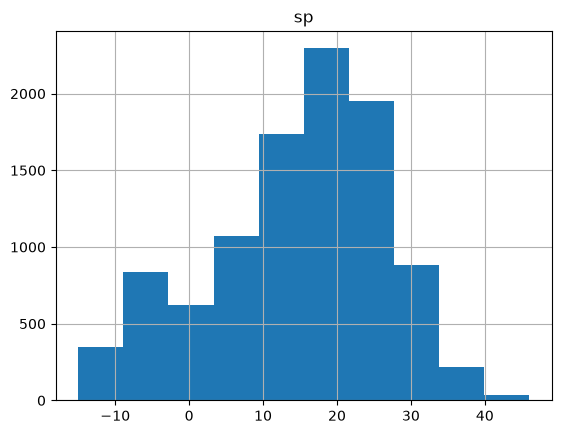

In [17]:
df.hist("sp")

<Axes: xlabel='sp', ylabel='zufriedenheit'>

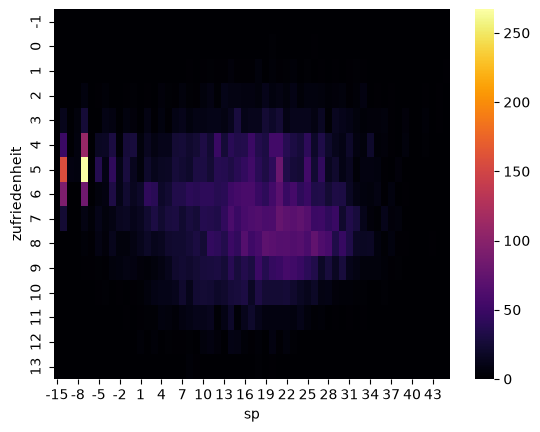

In [18]:
m = pd.crosstab( df['zufriedenheit'], df['sp'])
sns.heatmap(m,  cmap='inferno')

In [ ]:
final_games = (
    df
    .loc[df["runde"] == 4]
    .drop_duplicates(subset="game_id")
)

best_percent = (
    final_games
    .nlargest(max(1, round(len(final_games) * 0.01)), "sp")
    .copy()
)
best_percent[["game_id", "sp", "budget"]].head(10)

,game_id,sp,budget
10495,2623,46,-8
24623,6155,46,-8
24807,6201,46,-4
28855,7213,46,-4
147,36,45,-8
9011,2252,45,-8
11803,2950,45,-4
13019,3254,45,-4
13515,3378,45,-4
14339,3584,43,11


In [ ]:
slots = cards["Slot/Stapel"].unique()
single_slots = [slot for slot in slots if not slot.startswith("*")]

id_to_name = cards.set_index("id")["Name"].to_dict()
def map_cards(slot_values):
    return {
        slot_name: id_to_name.get(card_id)
        for slot_name, card_id in zip(single_slots, slot_values)
        if card_id >= 0
    }

best_percent["installed_cards"] = best_percent["slots"].apply(map_cards)
best_percent[
    ["game_id", "sp", "budget", "installed_cards"]
].head(20)


,game_id,sp,budget,installed_cards
10495,2623,46,-8,"{'Wärmeerzeugung': 'Zentrale Luftwärmepumpe', ..."
24623,6155,46,-8,{'Wärmeerzeugung': 'Dezentrale Luftwärmepumpe'...
24807,6201,46,-4,{'Wärmeerzeugung': 'Dezentrale Luftwärmepumpe'...
28855,7213,46,-4,{'Wärmeerzeugung': 'Dezentrale Luftwärmepumpe'...
147,36,45,-8,{'Wärmeerzeugung': 'Dezentrale Luftwärmepumpe'...
9011,2252,45,-8,{'Wärmeerzeugung': 'Dezentrale Luftwärmepumpe'}
11803,2950,45,-4,{'Wärmeerzeugung': 'Dezentrale Luftwärmepumpe'...
13019,3254,45,-4,{'Wärmeerzeugung': 'Dezentrale Luftwärmepumpe'...
13515,3378,45,-4,"{'Wärmeerzeugung': 'Zentrale Luftwärmepumpe', ..."
14339,3584,43,11,"{'Wärmeerzeugung': 'Fernwärme-Anschluss', 'Däm..."


In [ ]:
from collections import Counter
card_counts = Counter(
    card_name
    for cards in best_percent["installed_cards"]
    for card_name in cards.values()
)

card_frequency = (
    pd.DataFrame(
        card_counts.items(),
        columns=["Karte", "Anzahl_in_Top_1Prozent"]
    )
    .sort_values("Anzahl_in_Top_1Prozent", ascending=False)
    .reset_index(drop=True)
)

card_frequency["Anteil_Top_100"] = (
    card_frequency["Anzahl_in_Top_1Prozent"] / len(best_percent)
)

card_frequency.head(20)

,Karte,Anzahl_in_Top_100,Anteil_Top_100
0,Dezentrale Lüftungsgeräte,322,0.322
1,Niedertemperatur Radiator,304,0.304
2,Fernwärme-Anschluss,259,0.259
3,Tausch der Verglasung,226,0.226
4,Mechanische Abluftanlagen,224,0.224
5,Ambitionierte Sanierung ökologisch,205,0.205
6,Radiatoren mit Lüftern,191,0.191
7,Kleine Dach-PV-Anlage,190,0.190
8,Mittlere Dach-PV-Anlage,183,0.183
9,Dezentrale Luftwärmepumpe,180,0.180


In [ ]:
id_to_name = cards.set_index("id")["Name"].to_dict()

def extract_installed_cards(played_cards_log):
    return [
        id_to_name.get(entry["card_id"], f"Unknown card ID {entry['card_id']}")
        for entry in played_cards_log
    ]

best_percent["all_installed_cards"] = (
    best_percent["played_cards_log"].apply(extract_installed_cards)
)

best_percent[
    ["game_id", "sp", "all_installed_cards"]
].head(20)

,game_id,sp,all_installed_cards
10495,2623,46,"[Zentrale Luftwärmepumpe, Bi-Direktionelles La..."
24623,6155,46,"[Dezentrale Luftwärmepumpe, Mechanische Abluft..."
24807,6201,46,"[Dezentrale Luftwärmepumpe, Effiziente Haushal..."
28855,7213,46,"[LED Beleuchtung, Mittlere Dach-PV-Anlage, Bi-..."
147,36,45,"[Effiziente Haushaltsgeräte, Flexibles Lastman..."
9011,2252,45,"[Dezentrale Luftwärmepumpe, Fassadenintegriert..."
11803,2950,45,"[Grosse Dach-PV-Anlage, Bi-Direktionelles Lade..."
13019,3254,45,"[Grosse Dach-PV-Anlage, Effiziente Haushaltsge..."
13515,3378,45,"[Barrierefreier Zugang, Bi-Direktionelles Lade..."
14339,3584,43,"[Fernwärme-Anschluss, Mittlere Dach-PV-Anlage,..."


# Häufigkeit aller installierten Karten


In [ ]:
all_card_counts = Counter(
    card
    for cards in best_percent["all_installed_cards"]
    for card in cards
)

top_cards = (
    pd.DataFrame(
        all_card_counts.items(),
        columns=["Karte", "Anzahl"]
    )
    .sort_values("Anzahl", ascending=False)
    .reset_index(drop=True)
)

top_cards.head(20)

,Karte,Anzahl
0,Balkonkraftwerk,847
1,Bi-Direktionelles Laden,828
2,Effiziente Haushaltsgeräte,823
3,Flexibles Lastmanagement,822
4,Thermische Flexibilität,796
5,LED Beleuchtung,787
6,E-Herd,753
7,Barrierefreier Zugang,750
8,Wärmerückgewinnung des Duschwassers,740
9,Fassadenbegrünung,727


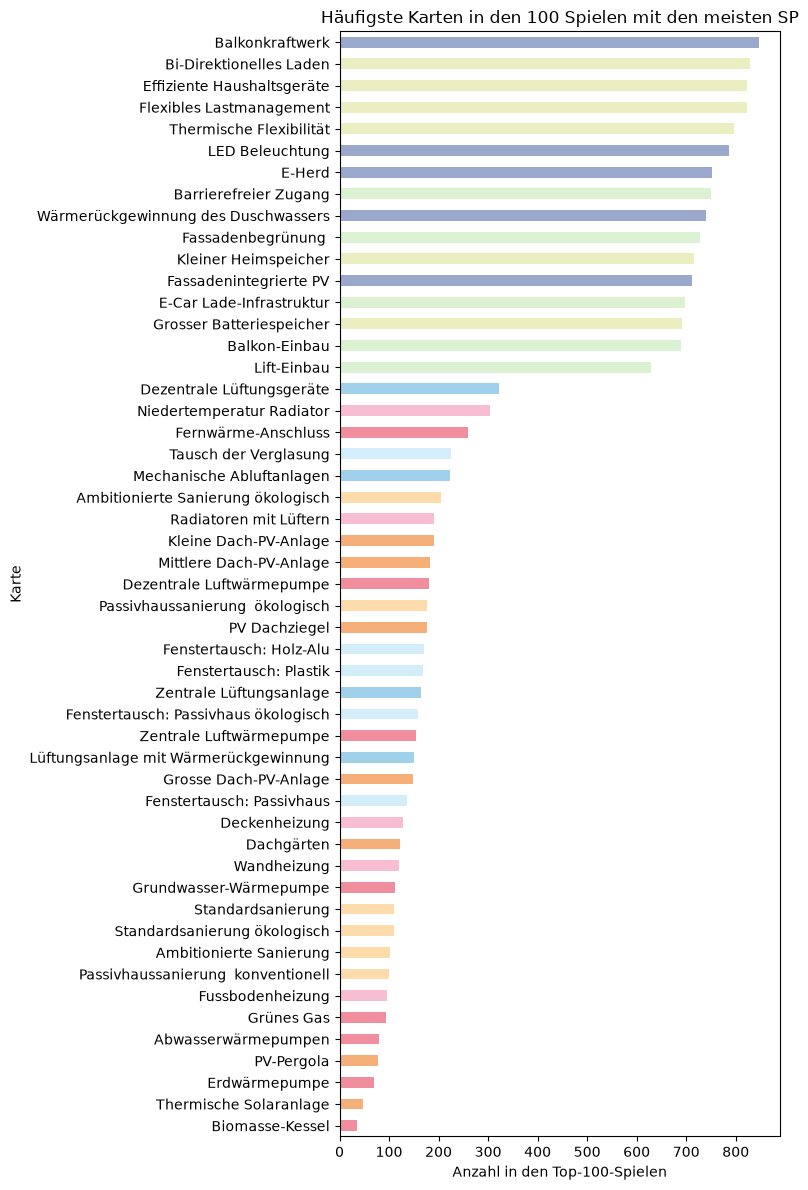

In [ ]:
# Slot information hinzufügen
from card_colors import slot_colors, default_color
plot_data = (
    top_cards
    .merge(
        cards[["Name", "Slot/Stapel"]],
        left_on="Karte",
        right_on="Name",
        how="left",
    )
    .drop(columns="Name")
    .sort_values("Anzahl")
)

bar_colors = (
    plot_data["Slot/Stapel"]
    .map(slot_colors)
    .fillna(default_color)
)

ax = plot_data.plot.barh(
    x="Karte",
    y="Anzahl",
    color=bar_colors,
    legend=False,
    figsize=(8, 12),
    title="Häufigste Karten in den Top 1% Spielen mit den meisten SP",
)

ax.set_xlabel("Anzahl in den Top-1%-Spielen")
ax.set_ylabel("Karte")

plt.tight_layout()
plt.show()